In [2]:
import kagglehub

path = kagglehub.dataset_download("oddrationale/mnist-in-csv")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Path to dataset files: /kaggle/input/mnist-in-csv


   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
Input Features: ['1x1', '1x2', '1x3', '1x4', '1x5'] ... Total features: 784
Target Variable: label
Train Dataset Shape: (60000, 785)
Test Dataset Shape: (10000

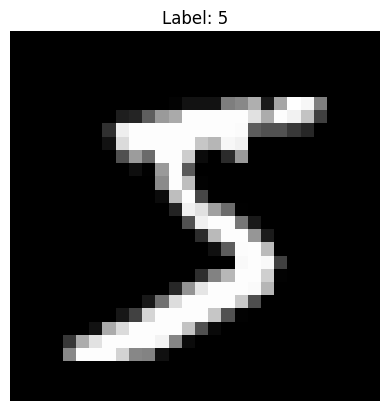

In [4]:
# Task 1
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv('/kaggle/input/mnist-in-csv/mnist_train.csv')
test_df = pd.read_csv('/kaggle/input/mnist-in-csv/mnist_test.csv')

print(train_df.head())

X_sample = train_df.drop(columns=['label'])
y_sample = train_df['label']

print("Input Features:", X_sample.columns.tolist()[:5], "... Total features:", X_sample.shape[1])
print("Target Variable: label")

print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)
train_df.info()

first_digit = X_sample.iloc[0].values.reshape(28, 28)
plt.imshow(first_digit, cmap='gray')
plt.title(f"Label: {y_sample.iloc[0]}")
plt.axis('off')
plt.show()

In [5]:
# Task 2
import numpy as np
from tensorflow.keras.utils import to_categorical

print("Train Missing Values:", train_df.isnull().sum().sum())
print("Test Missing Values:", test_df.isnull().sum().sum())

X_train = train_df.drop(columns=['label']).values
y_train = train_df['label'].values

X_test = test_df.drop(columns=['label']).values
y_test = test_df['label'].values

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

Train Missing Values: 0
Test Missing Values: 0


In [6]:
# Task 3
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test_encoded)
)

predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9301 - loss: 0.2417 - val_accuracy: 0.9546 - val_loss: 0.1456
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9694 - loss: 0.1024 - val_accuracy: 0.9709 - val_loss: 0.0924
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9785 - loss: 0.0691 - val_accuracy: 0.9736 - val_loss: 0.0882
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9831 - loss: 0.0544 - val_accuracy: 0.9728 - val_loss: 0.0903
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9865 - loss: 0.0414 - val_accuracy: 0.9775 - val_loss: 0.0727
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9893 - loss: 0.0328 - val_accuracy: 0.9770 - val_loss: 0.0856
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9907 - loss: 0.0280 - val_accuracy: 0.9790 - val_loss: 0.0789
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9917 - loss: 0.0249 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9778 - loss: 0.0899
Test Accuracy: 0.9778
Confusion Matrix:
[[ 972    2    0    2    0    0    2    1    1    0]
 [   0 1126    4    0    0    0    2    0    3    0]
 [   2    2 1013    6    1    0    1    3    4    0]
 [   0    0    5  995    0    1    0    4    2    3]
 [   1    2    4    0  962    0    4    1    2    6]
 [   2    1    0   11    2  865    6    1    4    0]
 [   7    3    1    0    3    1  941    0    2    0]
 [   2    7   12    4    1    1    1  992    3    5]
 [   5    2    4    8    3    2    3    2  943    2]
 [   2    5    1    6   12    2    1    3    8  969]]


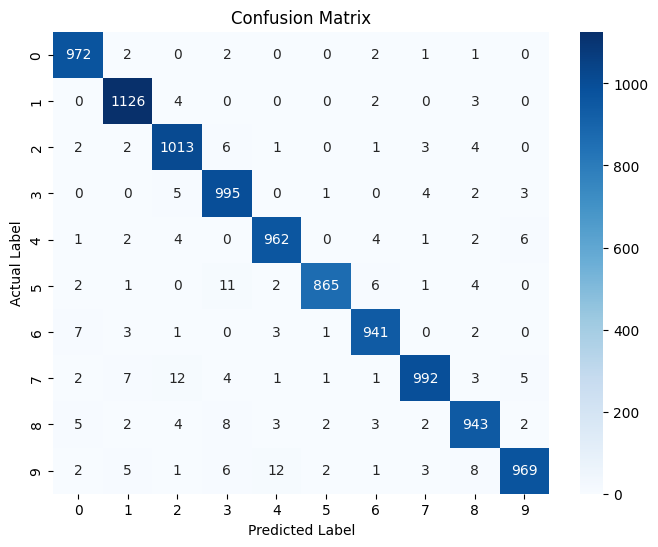

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.96      0.99      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.99      0.96      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



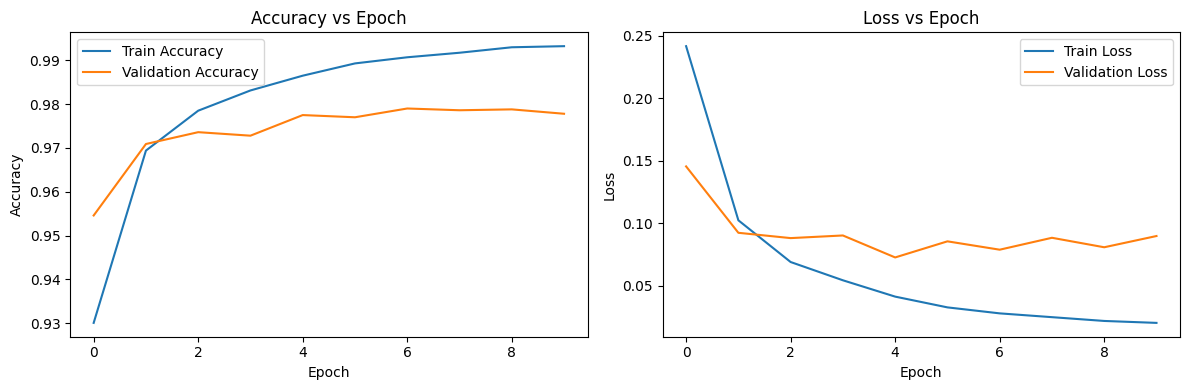

In [7]:
# Task 4
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(X_test, y_test_encoded)
print(f"Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(y_test, predicted_classes)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:")
print(classification_report(y_test, predicted_classes))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()

plt.tight_layout()
plt.show()

**Task 5**

Conclusion

The Artificial Neural Network achieved an overall test accuracy of 98% across 10,000 test samples, maintaining consistently strong performance across all digit classes with precision and recall ranging between 0.96 and 0.99. The two hidden layers (128 and 64 neurons with ReLU) were critical in enabling the network to learn non-linear patterns and construct abstract hierarchical representations from high-dimensional pixel inputs. A major advantage of Deep Learning over traditional Machine Learning is automated feature extraction directly from raw data, eliminating the need for complex, manual feature engineering. However, a key limitation of standard dense ANNs is that flattening 2D image matrices into 1D vectors destroys spatial relationships and localized structural context between adjacent pixels.